# Carga de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import random
import os

from torchvision import transforms
from sklearn.preprocessing import normalize
from PIL import Image
from tqdm import tqdm
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


# Carga de modelos

In [14]:
# Cargar el modelo DinoV2 desde torch hub
# https://github.com/facebookresearch/dinov2

#dino_v2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')
dino_v2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino_v2 = dino_v2.to(device)
dino_v2.eval()

print("¡Modelo DinoV2 cargado exitosamente!")
print(f"Dimensión de salida del modelo: {dino_v2.embed_dim}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


¡Modelo DinoV2 cargado exitosamente!
Dimensión de salida del modelo: 384


In [15]:
!gdown --id 1-LqJ2bS_T8XOx5TClDq31MCkPPoXO4bZ
!unzip dinov3-main.zip


# DINOv3 ViT models pretrained on web images
!gdown --id 1fH2rq53x6JY6zE_WBKH5vP_ZGq4jvj46
dino_v3 = torch.hub.load(repo_or_dir='./dinov3-main', model='dinov3_vits16plus', source='local', weights='dinov3_vits16plus_pretrain_lvd1689m-4057cbaa.pth')

# !gdown --id 1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m
# dino_v3 = torch.hub.load(repo_or_dir='./dinov3-main', model='dinov3_vitb16', source='local', weights='dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth')


# !gdown --id 1CfyML_a7PkVpt4Lhy-3yNxSfUgsFfgCs
# dino_v3 = torch.hub.load(repo_or_dir='./dinov3-main', model='dinov3_vitl16', source='local', weights='dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth')

dino_v3 = dino_v3.to(device)
dino_v3.eval()

print("¡Modelo DinoV3 cargado exitosamente!")
print(f"Dimensión de salida del modelo: {dino_v3.embed_dim}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-LqJ2bS_T8XOx5TClDq31MCkPPoXO4bZ
To: /content/dinov3-main.zip
100% 10.3M/10.3M [00:00<00:00, 304MB/s]
Archive:  dinov3-main.zip
adc254450203739c8149213a7a69d8d905b4fcfa
replace dinov3-main/.docstr.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: dinov3-main/.docstr.yaml  
  inflating: dinov3-main/.github/workflows/lint.yaml  
  inflating: dinov3-main/.gitignore  
  inflating: dinov3-main/CODE_OF_CONDUCT.md  
  inflating: dinov3-main/CONTRIBUTING.md  
  inflating: dinov3-main/LICENSE.md  
  inflating: dinov3-main/MODEL_CARD.md  
  inflating: dinov3-main/README.md   
  inflating: dinov3-main/conda.yaml  
  inflating: dinov3-main/dinov3/__init__.py  
  inflating: dinov3-main/dinov3/checkpointer/__init__.py  
 

100%|██████████| 110M/110M [00:00<00:00, 761MB/s] 


¡Modelo DinoV3 cargado exitosamente!
Dimensión de salida del modelo: 384


# Carga de imágenes

In [17]:
# Descargar el archivo zip desde Google Drive
!gdown --id 11-TD6add7zZaukIB8l2cVnBTJgsTjo8n

# Descomprimir el archivo
!unzip dataset_ecom_mini.zip

# Cargar los metadatos del conjunto de datos
data_dir = Path('eval')
df = pd.read_csv('eval.csv', delimiter=';')

print(f"El conjunto de datos contiene {len(df)} imágenes")
print(f"\nDistribución de categorías:")
print(df['GlobalCategoryEN'].value_counts())


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11-TD6add7zZaukIB8l2cVnBTJgsTjo8n
To: /content/dataset_ecom_mini.zip
100% 10.6M/10.6M [00:00<00:00, 110MB/s]
Archive:  dataset_ecom_mini.zip
replace eval/45elec.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: eval/45elec.jpg         
  inflating: eval/im.qf53qh.input.jpg  
  inflating: eval/8toys.jpg          
  inflating: eval/im.rf7hhh.input.jpg  
  inflating: eval/im.rys7rv.input.jpg  
  inflating: eval/226pets.jpg        
  inflating: eval/0off.jpg           
  inflating: eval/im.7wd4b3.input.jpg  
  inflating: eval/443pets.jpg        
  inflating: eval/im.yy3v67.input.jpg  
  inflating: eval/im.zu5wxi.input.jpg  
  inflating: eval/39pets.jpg         
  inflating: eval/24elec.jpg         
  inflating: ev

# Paso 3:

In [26]:
def transform(image):
    transform_pipeline = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return transform_pipeline(image)

def encode_image(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model(img_tensor)

    return features.cpu().numpy().flatten()


def generar_embeddings(model, df, data_dir, nombre_modelo):
    """
    Genera los embeddings para todas las imágenes de df['Title'] usando un modelo.
    Retorna embeddings (np.array) y los nombres válidos.
    """
    embeddings = []
    valid_names = []

    print(f"\n Generando embeddings con {nombre_modelo}...")
    model.eval()
    model.to(device)

    for filename in tqdm(df['Title'].values):
        img_path = data_dir / f"{filename}.jpg"
        if img_path.exists():
            try:
                img = Image.open(img_path).convert('RGB')
                img_tensor = transform(img).unsqueeze(0).to(device)
                with torch.no_grad():
                    feat = model(img_tensor)
                embeddings.append(feat.cpu().numpy().flatten())
                valid_names.append(filename)
            except Exception as e:
                print(f"Error con {filename}: {e}")

    embeddings = np.array(embeddings)
    print(f"{len(embeddings)} imágenes procesadas con {nombre_modelo}")
    return embeddings, valid_names




# Paso 4

In [27]:
# Función auxiliar para calcular similitud coseno
def cosine_similarity(vec1, vec2):
    """
    vec1, vec2: (numpy arrays)
    Puntuación de similitud entre 0 y 1 (1 = idéntico)
    """
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2)



def calcular_similitud(embeddings):
    """
    embeddings: matriz N x D
    Retorna la matriz N x N de similitud coseno.
    """
    embeddings_normalized = normalize(embeddings, axis=1)
    similarity_matrix = np.dot(embeddings_normalized, embeddings_normalized.T)
    return similarity_matrix



def display_image_comparison(img_paths, titles, similarities=None):
    """
    Muestra imágenes lado a lado con sus títulos y puntuaciones de similitud.
    """
    n_images = len(img_paths)
    fig, axes = plt.subplots(1, n_images, figsize=(5*n_images, 5))

    if n_images == 1:
        axes = [axes]

    for idx, (img_path, title) in enumerate(zip(img_paths, titles)):
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')

        if similarities is not None and idx > 0:
            axes[idx].set_title(f"{title}\nSimilitud: {similarities[idx-1]:.4f}", fontsize=12)
        else:
            axes[idx].set_title(title, fontsize=12)

    plt.tight_layout()
    plt.show()

In [28]:
def procesar_varios_modelos(modelos_dict, df, data_dir):
    """
    modelos_dict: {nombre_modelo: modelo_torch}
    df: dataframe con columna 'Title'
    """
    resultados = {}

    for nombre, modelo in modelos_dict.items():
        emb, valid_names = generar_embeddings(modelo, df, data_dir, nombre)
        sim = calcular_similitud(emb)
        resultados[nombre] = {
            'embeddings': emb,
            'valid_names': valid_names,
            'similarity_matrix': sim
        }
        print(f"💾 {nombre}: embeddings {emb.shape}, matriz {sim.shape}")

    return resultados


# --- 5️⃣ Ejemplo de uso ---
data_dir = Path('eval')

# Aquí puedes ir agregando tus modelos libremente:
modelos_dict = {
    'DINOv2': dino_v2,
    'DINOv3': dino_v3,
    # 'CLIP_ViT': clip_model,  # ejemplo futuro
}

# Procesar todos automáticamente
resultados = procesar_varios_modelos(modelos_dict, df, data_dir)

# Ejemplo de acceso:
# resultados['DINOv3']['similarity_matrix']
# resultados['DINOv2']['embeddings']



 Generando embeddings con DINOv2...


100%|██████████| 300/300 [00:03<00:00, 75.63it/s]


300 imágenes procesadas con DINOv2
💾 DINOv2: embeddings (300, 384), matriz (300, 300)

 Generando embeddings con DINOv3...


100%|██████████| 300/300 [00:05<00:00, 51.11it/s]

300 imágenes procesadas con DINOv3
💾 DINOv3: embeddings (300, 384), matriz (300, 300)


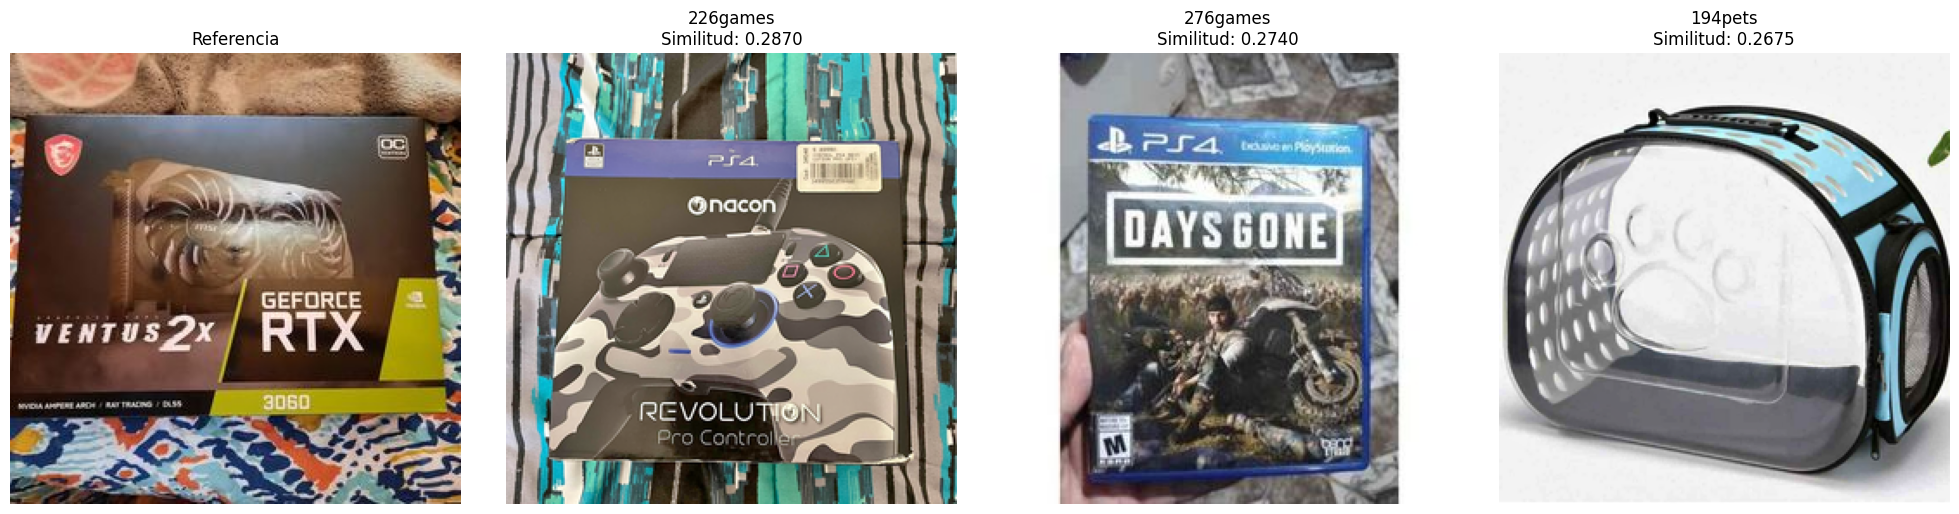

In [34]:
nombre_modelo = 'DINOv3'
sim_matrix = resultados[nombre_modelo]['similarity_matrix']
valid_names = resultados[nombre_modelo]['valid_names']

# Mostrar similitud entre imagen[0] y otras
idx_ref = 95
top_idx = np.argsort(sim_matrix[idx_ref])[::-1][1:4]  # las 3 más similares
sim_values = sim_matrix[idx_ref, top_idx]

img_paths = [data_dir / f"{valid_names[idx_ref]}.jpg"] + [data_dir / f"{valid_names[i]}.jpg" for i in top_idx]
titles = ["Referencia"] + [valid_names[i] for i in top_idx]

display_image_comparison(img_paths, titles, similarities=sim_values)

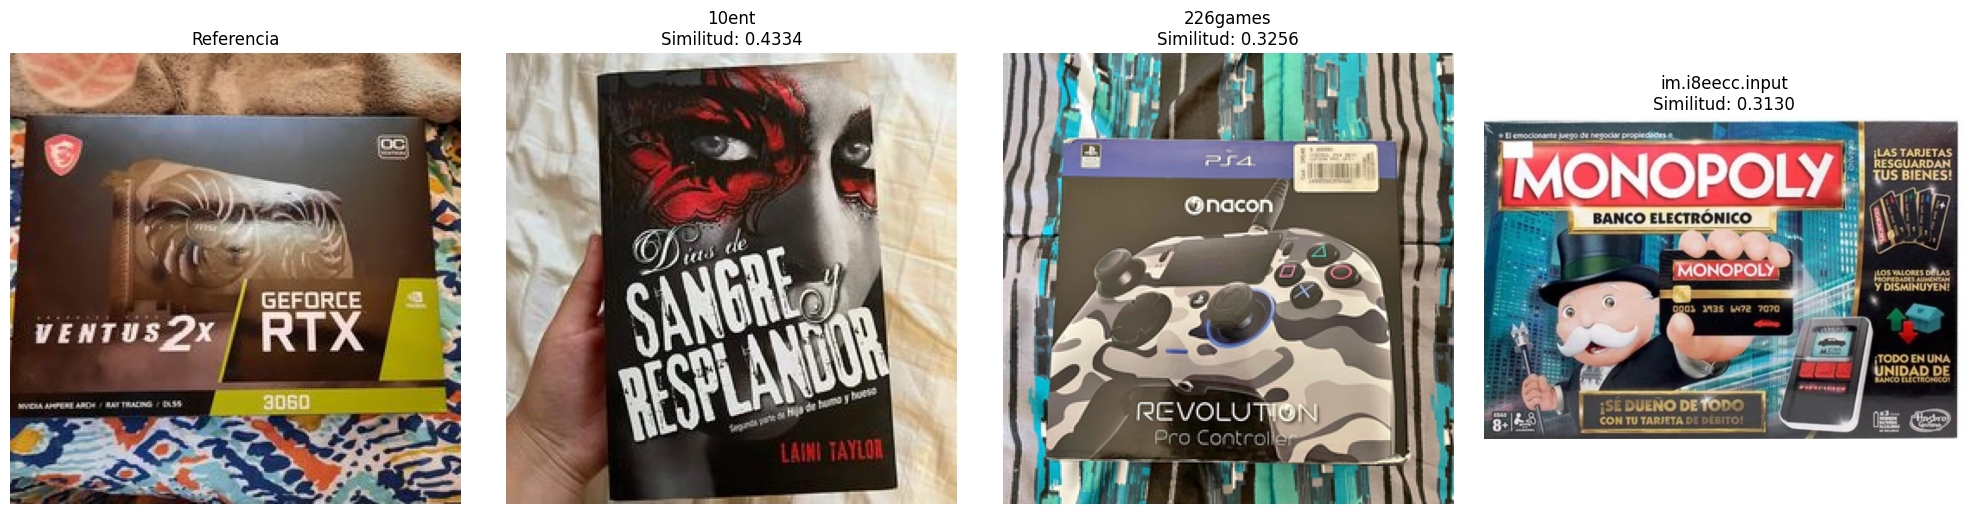

In [35]:
nombre_modelo = 'DINOv2'
sim_matrix = resultados[nombre_modelo]['similarity_matrix']
valid_names = resultados[nombre_modelo]['valid_names']

# Mostrar similitud entre imagen[0] y otras
idx_ref = 95
top_idx = np.argsort(sim_matrix[idx_ref])[::-1][1:4]  # las 3 más similares
sim_values = sim_matrix[idx_ref, top_idx]

img_paths = [data_dir / f"{valid_names[idx_ref]}.jpg"] + [data_dir / f"{valid_names[i]}.jpg" for i in top_idx]
titles = ["Referencia"] + [valid_names[i] for i in top_idx]

display_image_comparison(img_paths, titles, similarities=sim_values)

In [36]:
def compute_average_precision(query_idx, similarity_matrix, valid_filenames, df, k=None):
    """
    Calcula la Precisión Promedio (AP) para una sola consulta.

    Args:
        query_idx: índice de la imagen de consulta.
        similarity_matrix: matriz N x N de similitudes.
        valid_filenames: lista de nombres válidos (en el mismo orden que similarity_matrix).
        df: DataFrame original con 'Title' y 'GlobalCategoryEN'.
        k: número de resultados top a considerar (None = todos los resultados).

    Returns:
        average_precision (float), num_relevant (int)
    """
    # --- Categoría de la consulta ---
    query_filename = valid_filenames[query_idx]
    query_category = df.loc[df['Title'] == query_filename, 'GlobalCategoryEN'].values[0]

    # --- Categorías de todas las imágenes ---
    categories = [
        df.loc[df['Title'] == fn, 'GlobalCategoryEN'].values[0]
        for fn in valid_filenames
    ]

    # --- Máscara de elementos relevantes ---
    relevant_mask = np.array([cat == query_category for cat in categories])
    relevant_mask[query_idx] = False  # excluir la misma imagen
    num_relevant = relevant_mask.sum()

    if num_relevant == 0:
        return 0.0, 0

    # --- Ordenar por similitud (descendente) ---
    similarities = similarity_matrix[query_idx]
    ranked_indices = np.argsort(similarities)[::-1]

    # Eliminar el índice de la consulta
    ranked_indices = ranked_indices[ranked_indices != query_idx]

    # Limitar a top-K si se solicita
    if k is not None:
        ranked_indices = ranked_indices[:k]

    # --- Calcular AP ---
    precision_sum = 0.0
    num_relevant_seen = 0

    for i, idx in enumerate(ranked_indices):
        if relevant_mask[idx]:
            num_relevant_seen += 1
            precision_at_i = num_relevant_seen / (i + 1)
            precision_sum += precision_at_i

    average_precision = precision_sum / num_relevant
    return average_precision, num_relevant


# --- 2️⃣ Calcular Mean Average Precision (MAP) ---
def compute_MAP(similarity_matrix, valid_filenames, df, k=None):
    """
    Calcula la Media de Precisión Promedio (MAP) sobre todas las imágenes de consulta.

    Args:
        similarity_matrix: matriz N x N de similitudes.
        valid_filenames: lista de nombres válidos.
        df: DataFrame con columnas 'Title' y 'GlobalCategoryEN'.
        k: número de resultados top a considerar (None = todos los resultados).

    Returns:
        mean_ap: precisión promedio global
        per_image_ap: lista con el AP individual de cada imagen
    """
    aps = []
    total_relevant = 0

    for i in range(len(valid_filenames)):
        ap, n_rel = compute_average_precision(i, similarity_matrix, valid_filenames, df, k)
        aps.append(ap)
        total_relevant += n_rel

    mean_ap = np.mean(aps)
    print(f"📊 MAP@{k if k else 'all'} = {mean_ap:.4f}  (promedio sobre {len(valid_filenames)} consultas)")
    return mean_ap, aps


# --- 3️⃣ Ejemplo de uso con tus resultados ---
# Supongamos que ya tienes tus embeddings y similitud para cada modelo:
# resultados = procesar_varios_modelos(modelos_dict, df, data_dir)

for nombre, res in resultados.items():
    sim = res['similarity_matrix']
    valid_names = res['valid_names']
    mean_ap, _ = compute_MAP(sim, valid_names, df, k=10)
    print(f"✅ MAP@10 para {nombre}: {mean_ap:.4f}")



📊 MAP@10 = 0.1611  (promedio sobre 300 consultas)
✅ MAP@10 para DINOv2: 0.1611
📊 MAP@10 = 0.1646  (promedio sobre 300 consultas)
✅ MAP@10 para DINOv3: 0.1646
